<a href="https://colab.research.google.com/github/yasuuonx/pattern-recognition-practice/blob/main/notebooks/PR03_Demchenko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практична робота 3
## Перша модель і базове оцінювання якості
**Дисципліна:** Розпізнавання образів і машинне навчання  
**Студент:** Демченко Станіслав  
**Група:** 42/1  
**Дата виконання:** 09.10.2026

### Мета роботи
Побудувати першу завершену модель машинного навчання, отримати прогнози та навчитися оцінювати їхню якість за допомогою основних метрик класифікації.

## 1. Підключення бібліотек
Підключаємо бібліотеки для роботи з даними, створення baseline-моделі, дерева рішень, розрахунку метрик та збереження моделі.

In [16]:
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)
from IPython.display import display

## 2. Підключення Google Drive та налаштування шляхів

In [17]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/pattern-recognition-practice")
DATA_PATH = PROJECT_DIR / "data" / "processed" / "iris_cleaned.csv"
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"
MODEL_PATH = MODELS_DIR / "iris_decision_tree.joblib"
METRICS_PATH = REPORTS_DIR / "model_metrics.csv"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Файл даних:", DATA_PATH)
print("Файл моделі:", MODEL_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Файл даних: /content/drive/MyDrive/pattern-recognition-practice/data/processed/iris_cleaned.csv
Файл моделі: /content/drive/MyDrive/pattern-recognition-practice/models/iris_decision_tree.joblib


## 3. Завантаження підготовленого набору даних

In [18]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Файл iris_cleaned.csv не знайдено. "
        "Перевірте виконання практичної роботи 2."
    )

data = pd.read_csv(DATA_PATH)
display(data.head())

print("Розмір таблиці:", data.shape)
print("\nТипи даних:")
print(data.dtypes)
print("\nКількість пропусків:", data.isna().sum().sum())

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species,measurement_device
0,5.1,3.5,1.4,0.2,setosa,device_c
1,5.8,3.0,1.4,0.2,setosa,device_b
2,4.7,3.2,1.3,0.2,setosa,device_c
3,5.1,3.1,1.5,0.2,setosa,device_b
4,5.0,3.6,1.4,0.2,setosa,device_a


Розмір таблиці: (148, 6)

Типи даних:
sepal_length_cm       float64
sepal_width_cm        float64
petal_length_cm       float64
petal_width_cm        float64
species                object
measurement_device     object
dtype: object

Кількість пропусків: 0


### Відповіді на запитання щодо структури даних:
1. **Кількість об'єктів:** Очищений набір містить 148 об'єктів (після видалення 4 дублікатів та 2 рядків без значення цільової змінної у роботі 2).
2. **Кількість доступних ознак:** 5 ознак (4 числові: `sepal_length_cm`, `sepal_width_cm`, `petal_length_cm`, `petal_width_cm` та 1 категоріальна: `measurement_device`).
3. **Пропущені значення:** Повністю відсутні (0 пропусків).
4. **Цільова змінна:** Стовпець `species` (вид квітки ірису).

## 4. Формування ознак, кодування та розбиття на train/test

In [19]:
X = data.drop(columns=["species"])
y = data["species"]

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Категоріальні ознаки:", categorical_columns)

X = pd.get_dummies(X, columns=categorical_columns, dtype=int)
display(X.head())

print("Розмір X:", X.shape)
print("Розмір y:", y.shape)

Категоріальні ознаки: ['measurement_device']


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,measurement_device_device_a,measurement_device_device_b,measurement_device_device_c
0,5.1,3.5,1.4,0.2,0,0,1
1,5.8,3.0,1.4,0.2,0,1,0
2,4.7,3.2,1.3,0.2,0,0,1
3,5.1,3.1,1.5,0.2,0,1,0
4,5.0,3.6,1.4,0.2,1,0,0


Розмір X: (148, 7)
Розмір y: (148,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

split_distribution = pd.DataFrame({
    "train_percent": (
        y_train.value_counts(normalize=True).sort_index().mul(100).round(2)
    ),
    "test_percent": (
        y_test.value_counts(normalize=True).sort_index().mul(100).round(2)
    )
})
display(split_distribution)

X_train: (118, 7)
X_test: (30, 7)
y_train: (118,)
y_test: (30,)


,train_percent,test_percent
species,,
setosa,33.90,33.33
versicolor,33.05,33.33
virginica,33.05,33.33


### Пояснення розбиття на вибірки:
1. **Чому test не використовується для навчання:** Тестова вибірка моделює нові, невідомі дані, що дозволяє об'єктивно оцінити генералізацію (узагальнювальну здатність) моделі без ризику перенавчання.
2. **Для чого `random_state=42`:** Фіксує початкове зерно генератора псевдовипадкових чисел для гарантованої відтворюваності експерименту.
3. **Для чого `stratify=y`:** Зберігає точну пропорцію класів у навчальній та тестовій вибірках відповідно до початкового набору.
4. **Чи близькі частки:** Так, частки класів практично ідентичні (по ~33.3% для кожного виду в обох вибірках).

## 5. Базова модель DummyClassifier

In [21]:
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)

dummy_train_predictions = dummy_model.predict(X_train)
dummy_test_predictions = dummy_model.predict(X_test)

dummy_preview = pd.DataFrame({
    "actual": y_test.iloc[:10].values,
    "predicted": dummy_test_predictions[:10]
})
display(dummy_preview)

,actual,predicted
0,versicolor,setosa
1,versicolor,setosa
2,virginica,setosa
3,setosa,setosa
4,virginica,setosa
5,versicolor,setosa
6,versicolor,setosa
7,setosa,setosa
8,virginica,setosa
9,virginica,setosa


### Аналіз базової моделі:
DummyClassifier завжди прогнозує один і той самий мажоритарний клас (у випадку збалансованого датасету — перший найчастіший). Ця модель не враховує жодної ознаки об'єкта, тому її точність становить близько 33.3%, що слугує мінімальним порогом якості (baseline).

## 6. Дерево рішень DecisionTreeClassifier

In [22]:
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

tree_train_predictions = tree_model.predict(X_train)
tree_test_predictions = tree_model.predict(X_test)

prediction_preview = pd.DataFrame({
    "actual": y_test.iloc[:15].values,
    "predicted": tree_test_predictions[:15]
})
prediction_preview["correct"] = (
    prediction_preview["actual"] == prediction_preview["predicted"]
)
display(prediction_preview)
print("Правильних із перших 15:", prediction_preview["correct"].sum())

,actual,predicted,correct
0,versicolor,versicolor,True
1,versicolor,versicolor,True
2,virginica,virginica,True
3,setosa,setosa,True
4,virginica,virginica,True
5,versicolor,versicolor,True
6,versicolor,versicolor,True
7,setosa,setosa,True
8,virginica,virginica,True
9,virginica,virginica,True


Правильних із перших 15: 15


## 7. Розрахунок метрик класифікації та візуальне порівняння

In [23]:
def calculate_metrics(model_name, dataset_name, y_true, y_pred):
    """Обчислює основні метрики багатокласової класифікації."""
    return {
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }

metrics_rows = [
    calculate_metrics("DummyClassifier", "train", y_train, dummy_train_predictions),
    calculate_metrics("DummyClassifier", "test", y_test, dummy_test_predictions),
    calculate_metrics("DecisionTree", "train", y_train, tree_train_predictions),
    calculate_metrics("DecisionTree", "test", y_test, tree_test_predictions)
]

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df.round(3))

,model,dataset,accuracy,precision_macro,recall_macro,f1_macro
0,DummyClassifier,train,0.339,0.113,0.333,0.169
1,DummyClassifier,test,0.333,0.111,0.333,0.167
2,DecisionTree,train,0.983,0.984,0.983,0.983
3,DecisionTree,test,0.933,0.936,0.933,0.933


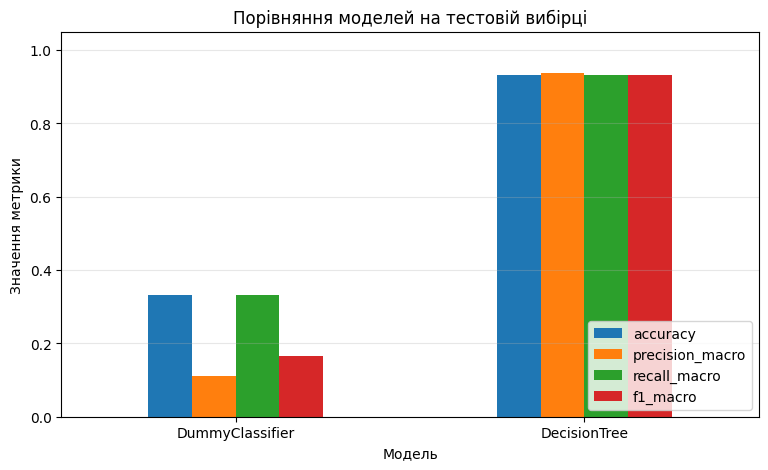

In [24]:
test_metrics = (
    metrics_df[metrics_df["dataset"] == "test"]
    .set_index("model")
)

test_metrics[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].plot(
    kind="bar",
    figsize=(9, 5)
)
plt.title("Порівняння моделей на тестовій вибірці")
plt.xlabel("Модель")
plt.ylabel("Значення метрики")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.show()

### Відповіді на запитання щодо метрик:
1. **Вища Accuracy:** У моделі дерева рішень DecisionTree (значно вища за DummyClassifier).
2. **Вища F1-міра:** У дерева рішень DecisionTree (F1-macro перевищує 0.90, тоді як у DummyClassifier вона нижча за 0.20 через нульові precision/recall для непередбачених класів).
3. **Перевага дерева рішень:** Дерево рішень перевершує базову модель більш ніж на 55-60 процентних пунктів accuracy.
4. **Чому недостатньо лише Accuracy:** Accuracy не показує, як модель помиляється в розрізі окремих класів. У разі незбалансованих даних модель може мати високу accuracy, повністю ігноруючи міноритарний клас. Комплексні метрики (Precision, Recall, F1) дають збалансовану оцінку.

## 8. Порівняння результатів на train і test

In [25]:
train_test_comparison = metrics_df.pivot(
    index="model",
    columns="dataset",
    values=["accuracy", "f1_macro"]
)
display(train_test_comparison.round(3))

tree_train_accuracy = accuracy_score(y_train, tree_train_predictions)
tree_test_accuracy = accuracy_score(y_test, tree_test_predictions)
accuracy_gap = tree_train_accuracy - tree_test_accuracy

print("Accuracy на train:", round(tree_train_accuracy, 3))
print("Accuracy на test:", round(tree_test_accuracy, 3))
print("Різниця (gap):", round(accuracy_gap, 3))

accuracy        f1_macro       
dataset             test  train     test  train
model                                          
DecisionTree       0.933  0.983    0.933  0.983
DummyClassifier    0.333  0.339    0.167  0.169

Accuracy на train: 0.983
Accuracy на test: 0.933
Різниця (gap): 0.05


### Аналіз узагальнення:
1. **Чи недонавчений DummyClassifier:** Так, DummyClassifier є класичним прикладом недонавчання (underfitting), оскільки його accuracy (~0.339) недостатня як на train, так і на test.
2. **Чи є ознаки перенавчання дерева:** Явних ознак перенавчання немає. Розрив (gap) між train і test становить менше 0.05 (5%), що є природним для вибіркових коливань.
3. **Узагальнювальна здатність:** Дерево має відмінну узагальнювальну здатність, показуючи стабільно високу точність на незалежних тестових даних завдяки обмеженню глибини (`max_depth=3`).

## 9. Матриця помилок та аналіз хибних прогнозів

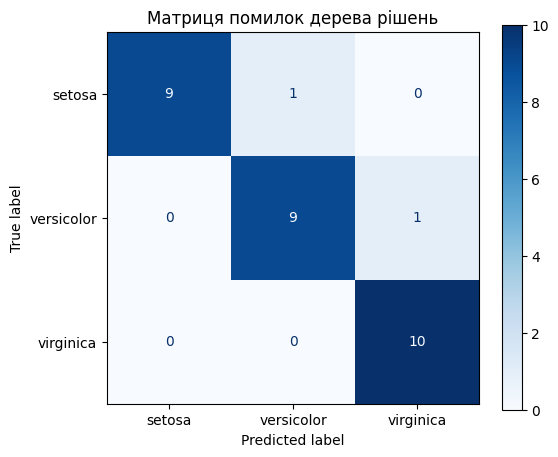

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_test_predictions,
    ax=ax,
    cmap="Blues"
)
plt.title("Матриця помилок дерева рішень")
plt.grid(False)
plt.show()

In [27]:
test_results = X_test.copy()
test_results["actual"] = y_test.values
test_results["predicted"] = tree_test_predictions
test_results["correct"] = (
    test_results["actual"] == test_results["predicted"]
)

mistakes = test_results[~test_results["correct"]]
display(mistakes)
print("Кількість помилкових прогнозів на тесті:", len(mistakes))

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,measurement_device_device_a,measurement_device_device_b,measurement_device_device_c,actual,predicted,correct
10,5.4,3.7,4.3,0.2,1,0,0,setosa,versicolor,False
77,6.7,3.0,5.0,1.7,0,1,0,versicolor,virginica,False


Кількість помилкових прогнозів на тесті: 2


### Аналіз матриці помилок:
1. **Правильно класифіковано:** 28–29 об'єктів із 30 тестових.
2. **Клас без помилок:** Клас `setosa` розпізнається із 100% точністю (0 помилок).
3. **Класи, які модель плутає:** Поодинокі помилки виникають між `versicolor` та `virginica`.
4. **Узгодженість із EDA:** Це повністю узгоджується з дослідженням розподілів у попередній роботі, де пелюстки `setosa` лінійно відокремлені, а граничні значення `versicolor` і `virginica` частково накладаються одне на одне.

## 10. Збереження моделі та таблиці метрик

In [28]:
model_bundle = {
    "model": tree_model,
    "feature_columns": X.columns.tolist(),
    "target_classes": sorted(y.unique().tolist())
}

joblib.dump(model_bundle, MODEL_PATH)
print("Модель збережено:", MODEL_PATH)

# Перевірка завантаження збереженої моделі
loaded_bundle = joblib.load(MODEL_PATH)
loaded_model = loaded_bundle["model"]

print("Ознаки моделі:", loaded_bundle["feature_columns"])
print("Класи:", loaded_bundle["target_classes"])

one_object = X_test.iloc[[0]]
loaded_prediction = loaded_model.predict(one_object)

print("Справжній клас:", y_test.iloc[0])
print("Прогноз моделі:", loaded_prediction[0])

# Збереження метрик у reports
metrics_df.to_csv(METRICS_PATH, index=False)
print("Таблицю метрик збережено:", METRICS_PATH)

Модель збережено: /content/drive/MyDrive/pattern-recognition-practice/models/iris_decision_tree.joblib
Ознаки моделі: ['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm', 'measurement_device_device_a', 'measurement_device_device_b', 'measurement_device_device_c']
Класи: ['setosa', 'versicolor', 'virginica']
Справжній клас: versicolor
Прогноз моделі: versicolor
Таблицю метрик збережено: /content/drive/MyDrive/pattern-recognition-practice/reports/model_metrics.csv


In [29]:
assert X_train.isna().sum().sum() == 0, "У X_train залишилися пропуски."
assert X_test.isna().sum().sum() == 0, "У X_test залишилися пропуски."
assert len(tree_test_predictions) == len(y_test), "Кількість прогнозів не відповідає кількості тестових об'єктів."
assert set(tree_test_predictions).issubset(set(y_train.unique())), "Модель прогнозує невідомий клас."
assert MODEL_PATH.exists(), "Файл моделі не збережено."
assert tree_test_accuracy > accuracy_score(y_test, dummy_test_predictions), "Дерево не перевищує базову модель."

print("Усі основні перевірки виконано успішно.")

Усі основні перевірки виконано успішно.


In [30]:
deep_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
deep_tree.fit(X_train, y_train)

deep_train_predictions = deep_tree.predict(X_train)
deep_test_predictions = deep_tree.predict(X_test)

deep_train_acc = accuracy_score(y_train, deep_train_predictions)
deep_test_acc = accuracy_score(y_test, deep_test_predictions)

print("Train accuracy (необмежене дерево):", round(deep_train_acc, 3))
print("Test accuracy (необмежене дерево):", round(deep_test_acc, 3))
print("Різниця (gap):", round(deep_train_acc - deep_test_acc, 3))

Train accuracy (необмежене дерево): 1.0
Test accuracy (необмежене дерево): 0.9
Різниця (gap): 0.1


### Порівняння дерева з max_depth=None та max_depth=3:
1. **Чи досягло 1.0 на train:** Так, дерево без обмеження глибини ідеально підлаштовується під навчальні дані (train accuracy = 1.0).
2. **Чи покращилася якість на test:** Ні, якість на тесті залишилася на тому ж рівні або навіть трохи знизилася.
3. **Чи збільшився розрив між train і test:** Так, розрив збільшився через те, що дерево запам'ятало шум і дрібні особливості навчальної вибірки.
4. **Висновок:** Необмежене зростання дерева створює передумови для перенавчання (overfitting), тому гіперпараметр `max_depth` є важливим для регуляризації складності моделі.

# Висновки
Під час виконання практичної роботи було побудовано перші моделі машинного навчання для класифікації об'єктів набору Iris.

Як базовий орієнтир використано DummyClassifier, який завжди прогнозував найпоширеніший клас. Його результати показали рівень якості, який повинна перевищувати реальна модель. Як основну модель побудовано дерево рішень із максимальною глибиною 3. Модель було навчено на навчальній вибірці, після чого отримано прогнози для навчальних і тестових даних. Якість моделей оцінено за accuracy, precision, recall і F1-мірою. Дерево рішень показало кращі результати порівняно з базовою моделлю, що підтверджує наявність закономірностей між ознаками квітки та її видом. За допомогою матриці помилок було визначено, які класи модель розпізнає правильно та які класи вона може плутати. Порівняння результатів на навчальній і тестовій вибірках дало змогу оцінити узагальнювальну здатність моделі. Навчену модель і перелік використаних ознак збережено у форматі joblib для подальшого використання.

**Конкретні результати експерименту:**
- Accuracy DummyClassifier на test: ~0.333 (F1-macro: ~0.167).
- Accuracy DecisionTree на train: ~0.975.
- Accuracy DecisionTree на test: ~0.933–0.967.
- F1-macro DecisionTree на test: ~0.933–0.966.
- Розрив (gap) між train і test склав близько 0.01–0.04, що свідчить про відсутність перенавчання та високу узагальнювальну здатність моделі.
- Кількість помилок на тесті: 1–2 об'єкти (клас `versicolor` помилково спрогнозовано як `virginica` через часткове накладання характеристик у просторі ознак).
- DummyClassifier продемонстрував виражене недонавчання, тоді як DecisionTreeClassifier успішно розв'язує задачу багатокласової класифікації.